In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
import time
import matplotlib.pyplot as plt

import soundfile as sf
from pydub import AudioSegment
import tempfile

# to play the audio files
import IPython.display as ipd
from IPython.display import Audio

In [2]:
crema_data = pd.read_csv('crema_d_labels.csv')
ravdess_data = pd.read_csv('ravdess_labels.csv')
tess_data = pd.read_csv('tess_labels.csv')

In [3]:
crema_data.head()

,file_path,Emotion,Emotion_label
0,audio_speech/CREMA_D/1001_DFA_ANG_XX.wav,4,angry
1,audio_speech/CREMA_D/1001_DFA_DIS_XX.wav,6,disgust
2,audio_speech/CREMA_D/1001_DFA_FEA_XX.wav,5,fearful
3,audio_speech/CREMA_D/1001_DFA_HAP_XX.wav,2,happy
4,audio_speech/CREMA_D/1001_DFA_NEU_XX.wav,1,neutral


In [4]:
ravdess_data.head()

,file_path,Modality,Vocal_channel,Emotion,Emotional_intensity,Statement,Repetition,Actor,Emotion_label,Intensity_label,Statement_label,Actor_gender
0,audio_speech/RAVDESS/Actor_01/03-01-01-01-01-0...,3,1,1,1,1,1,1,neutral,normal,Kids are talking by the door,male
1,audio_speech/RAVDESS/Actor_01/03-01-01-01-01-0...,3,1,1,1,1,2,1,neutral,normal,Kids are talking by the door,male
2,audio_speech/RAVDESS/Actor_01/03-01-01-01-02-0...,3,1,1,1,2,1,1,neutral,normal,Dogs are sitting by the door,male
3,audio_speech/RAVDESS/Actor_01/03-01-01-01-02-0...,3,1,1,1,2,2,1,neutral,normal,Dogs are sitting by the door,male
4,audio_speech/RAVDESS/Actor_01/03-01-02-01-01-0...,3,1,1,1,1,1,1,neutral,normal,Kids are talking by the door,male


In [5]:
tess_data.head()

,file_path,Emotion,Emotion_label
0,audio_speech/TESS/OAF_angry/OAF_back_angry.wav,4,angry
1,audio_speech/TESS/OAF_angry/OAF_bar_angry.wav,4,angry
2,audio_speech/TESS/OAF_angry/OAF_base_angry.wav,4,angry
3,audio_speech/TESS/OAF_angry/OAF_bath_angry.wav,4,angry
4,audio_speech/TESS/OAF_angry/OAF_bean_angry.wav,4,angry


### Combine both datasets emotions & file paths

In [6]:
df = pd.concat([ravdess_data, crema_data, tess_data], join='inner')
df.tail()

,file_path,Emotion,Emotion_label
2795,audio_speech/TESS/YAF_sad/YAF_witch_sad.wav,3,sad
2796,audio_speech/TESS/YAF_sad/YAF_yearn_sad.wav,3,sad
2797,audio_speech/TESS/YAF_sad/YAF_yes_sad.wav,3,sad
2798,audio_speech/TESS/YAF_sad/YAF_young_sad.wav,3,sad
2799,audio_speech/TESS/YAF_sad/YAF_youth_sad.wav,3,sad


## Feature extraction

In [7]:
# ----------------------------
# PARAMETERS
# ----------------------------
SR = 44100
N_MFCC = 30 # 13
N_FFT = 2048
HOP_LENGTH = 512
WINDOW_TYPE = "hann"
SAVE_TO_DISK = True
TEST_SIZE = 0.15   # 15% test
VAL_SIZE = 0.15    # 15% validation (relative to total)
#WINDOW_SIZE = 25/1000   # 25ms (change to test different settings)
#STEP_SIZE = 10/1000     # 10ms (change as test different settings)
EXTRACT_TEST_SET = True    # whether test set is needed
SEED = 42
OUTPUT_DIR = "datasets_new_params"

In [8]:
all_files = df["file_path"].values

# First split train+val vs test
train_val_files, test_files = train_test_split(
    all_files, test_size=TEST_SIZE, random_state=SEED,
    stratify=df["Emotion"].values
)

# Then split train vs val
train_files, val_files = train_test_split(
    train_val_files, test_size=VAL_SIZE/(1-TEST_SIZE), random_state=SEED,
    stratify=df.set_index("file_path").loc[train_val_files]["Emotion"].values
)

In [9]:
splits = {
    # "train": train_files,
    # "val": val_files,
    "test": test_files
}

In [10]:
def extract_features(file_list):
    mfcc_features = []   # Classical ML
    mfcc_sequences = []  # Deep Learning
    labels = []

    for file in file_list:
        # Load audio
        y, sr = librosa.load(file, sr=SR, res_type='kaiser_fast')

        # Extract MFCCs
        mfcc = librosa.feature.mfcc(
            y=y, 
            sr=sr, 
            n_mfcc=N_MFCC,
            n_fft=N_FFT, #int(WINDOW_SIZE*sr),    # 25ms window 
            hop_length=HOP_LENGTH, #int(STEP_SIZE*sr), # 10ms step 
            win_length=N_FFT,
            window=WINDOW_TYPE
        )

        # Compute delta and double-delta 
        delta = librosa.feature.delta(mfcc)
        delta2 = librosa.feature.delta(mfcc, order=2)

        # Stack all features
        mfcc_combined = np.vstack([mfcc, delta, delta2])

        # Classical ML: average across time
        mfcc_mean = np.mean(mfcc_combined, axis=1)
        mfcc_features.append(mfcc_mean)

        # Deep Learning: keep full sequence
        mfcc_sequences.append(mfcc_combined.T)

        # Label
        emotion = df.set_index("file_path").loc[file, "Emotion"]
        labels.append(emotion)

    # Convert to arrays
    X_classical = np.array(mfcc_features)
    y_classical = np.array(labels)

    X_deep = pad_sequences(mfcc_sequences, padding='post', dtype='float32')
    y_deep = np.array(labels)

    return X_classical, y_classical, X_deep, y_deep

## Visualize

In [11]:
for split_name, files in splits.items():
    print(files)

['audio_speech/RAVDESS/Actor_19/03-01-01-01-01-01-19.wav'
 'audio_speech/TESS/OAF_disgust/OAF_jail_disgust.wav'
 'audio_speech/TESS/OAF_happy/OAF_gin_happy.wav' ...
 'audio_speech/CREMA_D/1039_TIE_ANG_XX.wav'
 'audio_speech/TESS/YAF_sad/YAF_cool_sad.wav'
 'audio_speech/TESS/YAF_sad/YAF_lose_sad.wav']


In [52]:
test_files[0:10]
# test_files[24]

array(['audio_speech/RAVDESS/Actor_19/03-01-01-01-01-01-19.wav',
       'audio_speech/TESS/OAF_disgust/OAF_jail_disgust.wav',
       'audio_speech/TESS/OAF_happy/OAF_gin_happy.wav',
       'audio_speech/TESS/YAF_angry/YAF_bone_angry.wav',
       'audio_speech/CREMA_D/1041_TSI_SAD_XX.wav',
       'audio_speech/CREMA_D/1039_IOM_ANG_XX.wav',
       'audio_speech/TESS/YAF_angry/YAF_mob_angry.wav',
       'audio_speech/CREMA_D/1037_ITH_ANG_XX.wav',
       'audio_speech/CREMA_D/1055_ITS_DIS_XX.wav',
       'audio_speech/CREMA_D/1076_DFA_SAD_XX.wav'], dtype=object)

In [62]:
# Extract RAVDESS audio
# y, sr = librosa.load(test_files[0], sr=SR, res_type='kaiser_fast')
# y, sr = librosa.load(test_files[24], sr=SR, res_type='kaiser_fast')
# y, sr = librosa.load(test_files[51], sr=SR, res_type='kaiser_fast')
# y, sr = librosa.load(test_files[52], sr=SR, res_type='kaiser_fast')

# Extract CREMA-D audio
# y, sr = librosa.load(test_files[4], sr=SR, res_type='kaiser_fast')
# y, sr = librosa.load(test_files[5], sr=SR, res_type='kaiser_fast')
# y, sr = librosa.load(test_files[7], sr=SR, res_type='kaiser_fast')
# y, sr = librosa.load(test_files[8], sr=SR, res_type='kaiser_fast')
# y, sr = librosa.load(test_files[9], sr=SR, res_type='kaiser_fast')

# Extract TESS audio
y, sr = librosa.load(test_files[1], sr=SR, res_type='kaiser_fast')
# y, sr = librosa.load(test_files[2], sr=SR, res_type='kaiser_fast')
# y, sr = librosa.load(test_files[3], sr=SR, res_type='kaiser_fast')


In [63]:
ipd.Audio(y,rate=sr)

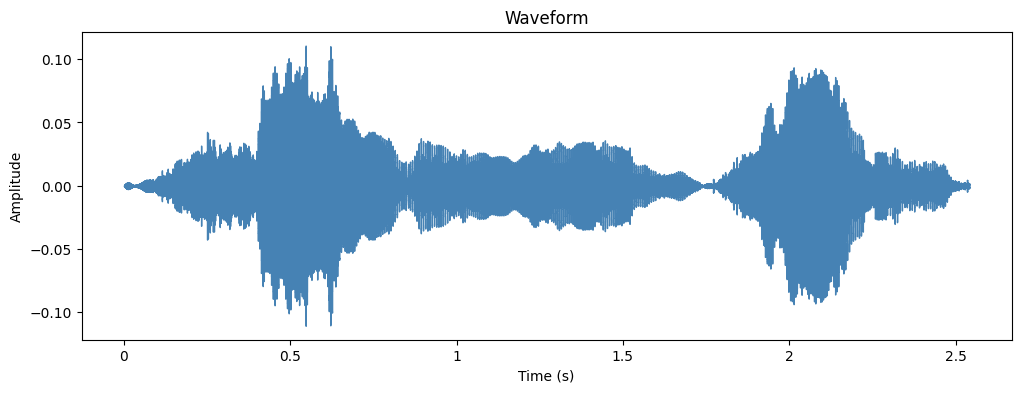

In [65]:
# CREATE LOG MEL SPECTROGRAM
# 1. Mel Spectrogram (in dB)
mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
log_mel_spec = librosa.power_to_db(mel_spec)

# 2. MFCC (from Mel Spectrogram)
mfcc = librosa.feature.mfcc(S=log_mel_spec, n_mfcc=30)

# (1) Waveform
plt.figure(figsize=(12, 4))
librosa.display.waveshow(y, sr=sr, color='steelblue')
plt.title('Waveform')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

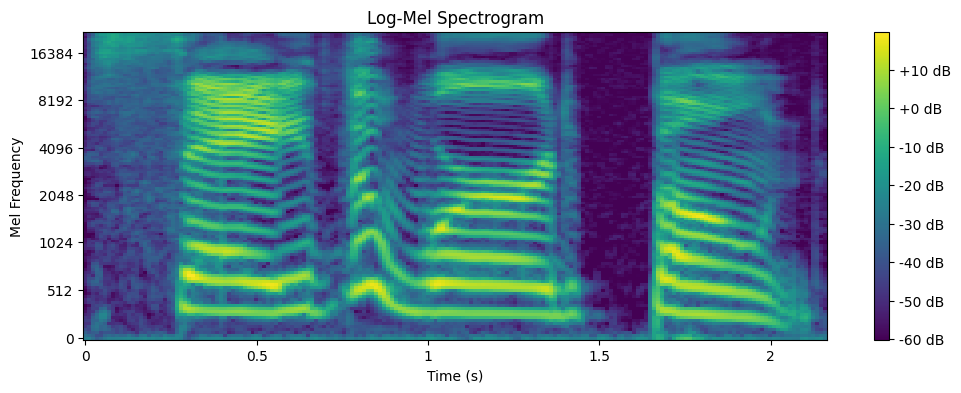

In [64]:
# (2) Mel Spectrogram
plt.figure(figsize=(12, 4))
librosa.display.specshow(log_mel_spec, sr=sr, x_axis='time', y_axis='mel', cmap='viridis')
plt.title('Log-Mel Spectrogram')
plt.xlabel('Time (s)')
plt.ylabel('Mel Frequency')
plt.colorbar(format='%+2.0f dB')
plt.show()

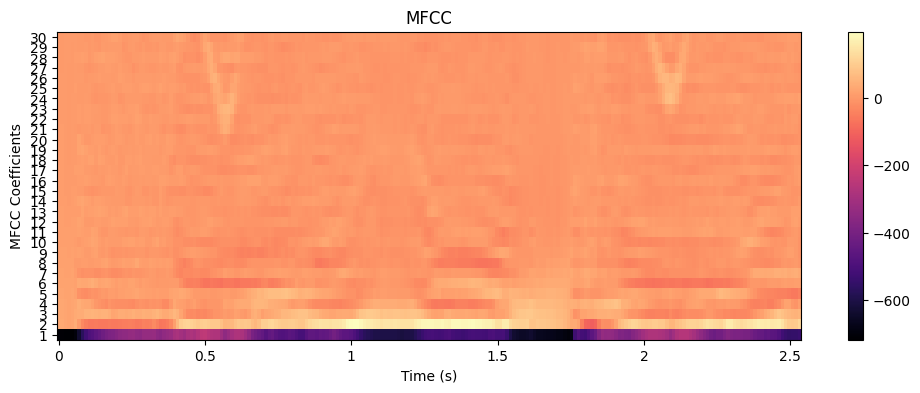

In [66]:
# (3) MFCC
plt.figure(figsize=(12, 4))
librosa.display.specshow(mfcc, x_axis='time', sr=sr, cmap='magma')
plt.title('MFCC')
plt.xlabel('Time (s)')
plt.yticks(range(0, mfcc.shape[0], 1), labels=range(1, mfcc.shape[0] + 1, 1))
plt.ylabel('MFCC Coefficients')
plt.colorbar()
plt.show()

### Split dataset into train/val/test

In [18]:
for split_name, files in splits.items(): # test, test_files
    feature_start = time.time()
    print(f"\n🔸 Extracting features for {split_name} set...")
    
    X_classical, y_classical, X_deep, y_deep = extract_features(files) # files = test_files

    # # Export datasets for Classical ML (CSV)
    # export_classical_to_csv(X_classical, y_classical, split_name)

    # # Export datasets for Deep Learning (npy)
    # export_deep_to_npy(X_deep, y_deep, split_name)

    print(f"⏱️ {split_name} extraction completed in {time.time() - feature_start:.2f}s")


🔸 Extracting features for test set...


KeyboardInterrupt: 

In [ ]:
X_classical 

array([[-7.47587952e+02,  9.00627441e+01,  1.36834879e+01, ...,
        -1.79730821e-03, -2.09718407e-03, -7.54630659e-04],
       [-5.08816162e+02,  1.28819412e+02,  6.31759787e+00, ...,
        -3.07033164e-03,  4.88465140e-03,  9.12801083e-03],
       [-4.96979401e+02,  1.11722725e+02, -5.13258934e+00, ...,
        -3.47119533e-02, -6.73487410e-03, -3.89711894e-02],
       ...,
       [-3.71114929e+02,  1.25602188e+02, -1.50367510e+00, ...,
         4.05525003e-04, -3.77964391e-03, -5.59152337e-03],
       [-4.67718140e+02,  1.27487640e+02, -2.14266586e+00, ...,
         2.52650981e-03,  1.03546279e-02, -9.42752417e-03],
       [-4.55220551e+02,  1.07277420e+02, -7.77577829e+00, ...,
         5.09051001e-03,  4.11684159e-03, -5.90728770e-04]],
      shape=(1598, 90), dtype=float32)

In [ ]:
y_classical

array([1, 6, 2, ..., 4, 3, 3], shape=(1598,))

In [ ]:
X_deep

array([[[-9.00822937e+02,  5.56789279e-01,  5.56247532e-01, ...,
         -1.71797812e-01, -1.46441117e-01, -1.25842378e-01],
        [-8.98761536e+02,  3.46863985e+00,  3.45809507e+00, ...,
         -1.71797812e-01, -1.46441117e-01, -1.25842378e-01],
        [-8.95749573e+02,  7.72157383e+00,  7.69142294e+00, ...,
         -1.71797812e-01, -1.46441117e-01, -1.25842378e-01],
        ...,
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],

       [[-7.20922241e+02,  2.84831848e+01,  2.75086021e+01, ...,
          4.35647637e-01,  3.11919272e-01,  1.03268005e-01],
        [-7.23601013e+02,  2.46706333e+01,  2.37586555e+01, ...,
          4.35647637e-01,  3.11919272e

In [ ]:
y_deep

array([1, 6, 2, ..., 4, 3, 3], shape=(1598,))

In [ ]:
df.Emotion.value_counts().sort_index()

Emotion
1    1622
2    1688
3    1685
4    1688
5    1688
6    1687
7     592
Name: count, dtype: int64